# Figure 4 - Learning DendI representation for Dend Target Prop

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
figure_name = "Fig3_dendI"
model_list = ["bpLike_WT_fixedDend", "bpLike_WT_localBP", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

In [16]:
def generate_figure_4(model_dict_all, model_list, figure_name):
    fig = plt.figure(figsize=(6.5, 9))
    axes = gs.GridSpec(nrows=3, ncols=4, figure=fig,            
                       left=0.049,right=0.95,
                       top=0.95, bottom=0.5,
                       wspace=0.2, hspace=0.5,
                       width_ratios=[1, 1, 1, 0.1])
    
    metrics_axes = gs.GridSpec(nrows=3, ncols=4, figure=fig,
                       left=0.049,right=0.98,
                       top=0.95, bottom=0.55,
                       wspace=0.4, hspace=0.6,
                       width_ratios=[1, 1, 1, 0.4])
    ax_accuracy    = fig.add_subplot(metrics_axes[1, 0])
    ax_dendstate   = fig.add_subplot(metrics_axes[1, 1])
    ax_angle       = fig.add_subplot(metrics_axes[1, 2])
    ax_selectivity = fig.add_subplot(metrics_axes[1, 3])
    root_dir = ut.get_project_root()

    if "bpLike_WT_hebbdend" in model_dict_all: # Update model label for this figure
        model_dict_all["bpLike_WT_hebbdend"]["label"] = "Learned (Hebb)"
        
    for col, model_key in enumerate(model_list):
        model_dict = model_dict_all[model_key]
        network_name = model_dict['config'].split('.')[0]
        hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"

        with h5py.File(hdf5_path, 'r') as f:
            data_dict = f[network_name]
            print(f"Generating plots for {model_dict['label']}")
            populations_to_plot = ['H2DendI']

            # Plot heatmaps
            for row,population in enumerate(populations_to_plot):
                # Activity plots: batch accuracy of each population to the test dataset
                ax = fig.add_subplot(axes[row, col])
                seed = model_dict['seeds'][0] # example seed to plot
                average_pop_activity_dict = data_dict[seed]['average_pop_activity_dict']
                num_units = average_pop_activity_dict[population].shape[1]
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)

                ax.set_yticks([0,num_units-1])
                ax.set_yticklabels([1,num_units])
                ax.set_ylabel(f'{population} unit', labelpad=-8)
                if row==0:
                    ax.set_title(model_dict["display_name"], pad=3)
                if col>0:
                    ax.set_ylabel('')
                    ax.set_yticklabels([])

            # Plot metrics
            plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy)
            plot_dendritic_state_all_seeds(data_dict, model_dict, ax=ax_dendstate)
            plot_angle_vs_bp_all_seeds(data_dict, model_dict, ax=ax_angle)

            populations_to_plot = [population for population in data_dict[seed]['average_pop_activity_dict'] if 'DendI' in population]
            plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin')

            legend = ax_accuracy.legend(ncol=1, bbox_to_anchor=(0.2, 0.6), loc='upper left', fontsize=6)
            for line in legend.get_lines():
                line.set_linewidth(1.5)

    # fig.savefig(f"figures/{figure_name}.png", dpi=300)
    # fig.savefig(f"figures/{figure_name}.svg", dpi=300)

Generating plots for Fixed random
Generating plots for Learned (Backprop)
Generating plots for Learned (Hebb)


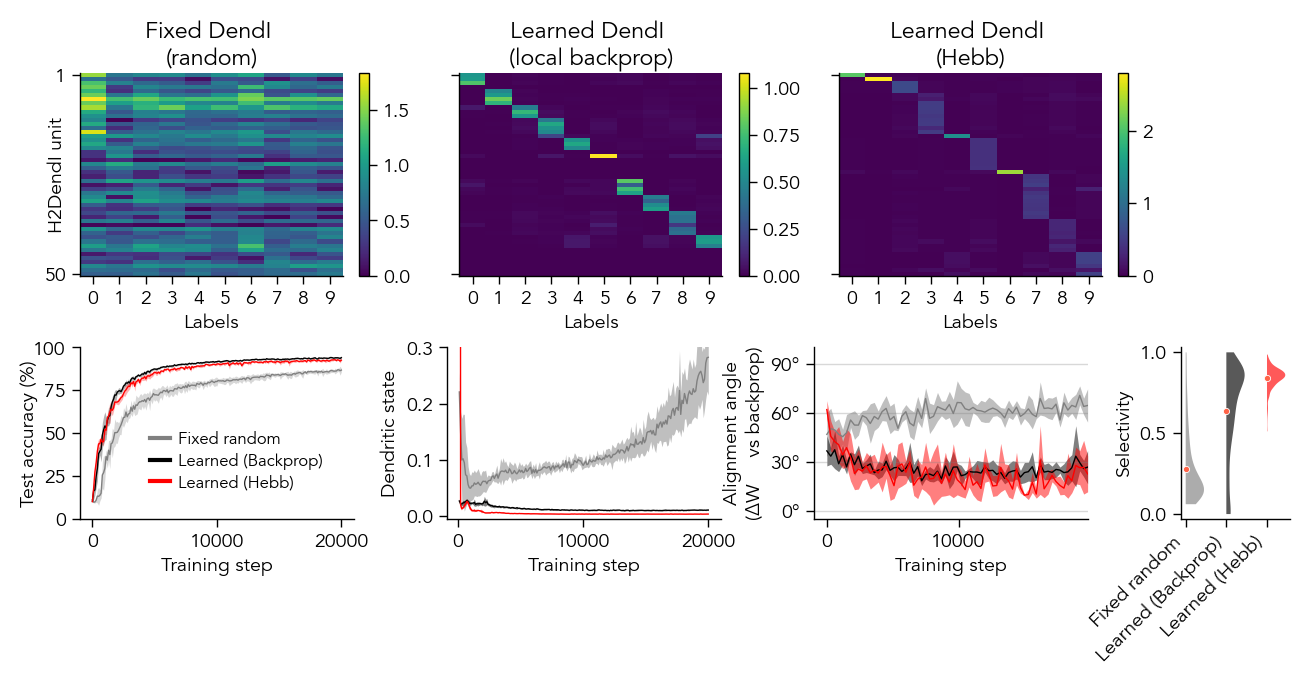

In [15]:
generate_figure_4(model_dict_all, model_list, figure_name)